# CTMC Journey Models: Success vs 60-Day Inactivity Failure

This notebook compares the retained CTMC baselines against two timeout-aware models. The key target distinction is:

- old CTMC target: `P(hit order_shipped state 28 within a horizon | current state)`
- classification target: `P(success before failure by 60 days of customer inactivity | current state)`

Company/system events are not treated as customer actions for the inactivity clock.

In [1]:
from pathlib import Path
import os
import sys

# Prevent Windows MKL/OpenMP hangs in sklearn clustering cells.
os.environ.setdefault("OMP_NUM_THREADS", "1")
os.environ.setdefault("MKL_NUM_THREADS", "1")
os.environ.setdefault("OPENBLAS_NUM_THREADS", "1")
os.environ.setdefault("NUMEXPR_NUM_THREADS", "1")

PROJECT_ROOT = Path.cwd().resolve()
while PROJECT_ROOT != PROJECT_ROOT.parent and not (PROJECT_ROOT / "requirements.txt").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

sys.path.insert(0, str(PROJECT_ROOT / "src" / "models"))
sys.path.insert(0, str(PROJECT_ROOT / "src" / "visualizations"))

import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import average_precision_score, brier_score_loss, log_loss, roc_auc_score

from ctmc import (
    CTMCData,
    ClusteredCTMC,
    GlobalCTMC,
    SemiMarkovTimeoutModel,
    TimeoutAbsorbingCTMC,
    FAILURE_STATE,
    SUCCESS_STATE,
)
from ctmc_plots import (
    plot_aesthetic_state_space_graph,
    plot_generator_heatmap,
    plot_journey_success_probability_over_time,
    plot_top_transition_graph,
    plotly_timeout_probability_over_time,
)
from IPython.display import Image

MAX_JOURNEYS = 100_000
N_CLUSTERS = 3
USE_SPECTRAL_CLUSTERING = False
RESULTS_DIR = PROJECT_ROOT / "results"
RESULTS_DIR.mkdir(exist_ok=True)

pd.set_option("display.max_columns", 80)

## Event Definitions and State Choice

The event definition file mixes customer actions with company/system states. For inactivity failure, company/system events should not reset the 60-day clock. The models below use customer-action states plus terminal `order_shipped=28` where needed.

In [2]:
data = CTMCData()
event_defs = pd.read_csv(PROJECT_ROOT / "data" / "Event Definitions.csv")
customer_states = data.customer_action_states(include_success=False)

event_defs["used_as_customer_action_state"] = event_defs["event_definition_id"].isin(customer_states)
display(event_defs.sort_values("event_definition_id"))
print("Customer action states:", sorted(customer_states))
print("Success terminal state:", SUCCESS_STATE, "Failure terminal state:", FAILURE_STATE)

,event_name,journey_id,event_definition_id,milestone_number,stage,used_as_customer_action_state
10,campaign_click,1,2,NaN,Discover,True
6,application_web_submit,1,3,NaN,Apply for Credit,True
21,browse_products,1,4,NaN,First Purchase,True
24,view_cart,1,5,NaN,First Purchase,True
20,begin_checkout,1,6,NaN,First Purchase,True
23,place_order_web,1,7,2.0,First Purchase,True
17,place_downpayment,1,8,4.0,Downpayment,True
11,customer_requested_catalog_digital,1,9,NaN,Discover,True
12,fingerhut_university,1,10,NaN,Discover,True
19,add_to_cart,1,11,NaN,First Purchase,True


Customer action states: [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 18, 19, 22, 23, 25]
Success terminal state: 28 Failure terminal state: -1


## Build Transition Tables

`transitions` is the old CTMC transition table, but filtered to customer-action states plus success. `timeout_transitions` adds an absorbing failure state for incomplete journeys after 60 days with no customer action.

In [3]:
transitions = data.transition_table(
    max_journeys=MAX_JOURNEYS,
    customer_actions_only=True,
    include_success=True,
)
timeout_transitions = data.timeout_transition_table(max_journeys=MAX_JOURNEYS)

print("customer-action CTMC transitions:", transitions.shape, "journeys:", transitions["id"].nunique())
print("timeout-aware transitions:", timeout_transitions.shape, "journeys:", timeout_transitions["id"].nunique())
display(transitions.head())
display(timeout_transitions.tail())

customer-action CTMC transitions: (2731520, 4) journeys: 88648
timeout-aware transitions: (1385115, 4) journeys: 95083


,id,state,next_state,dt_seconds
1,-1000001271 551641434,4,19,24.0
2,-1000001271 551641434,19,19,3.0
3,-1000001271 551641434,19,19,2.0
4,-1000001271 551641434,19,2,21498.0
5,-1000001271 551641434,2,4,2846848.0


,id,state,next_state,dt_seconds
2746731,-1303783106 -1331962655,19,-1,5184000.0
2746732,-1303785126 -1269952066,4,-1,5184000.0
2746733,-1303788107 2139060553,18,-1,5184000.0
2746734,-1303796977 -1056334630,6,-1,5184000.0
2746735,-1303809893 284896680,4,-1,5184000.0


## Old Baseline 1: Global CTMC

This still computes `P(hit order_shipped within 60 days | current state)`. It is useful, but it is not the exact failure-vs-success target.

In [4]:
global_ctmc = GlobalCTMC().fit(transitions)
print("Q shape:", global_ctmc.Q_.shape)
display(global_ctmc.top_rates(20))

plot_generator_heatmap(global_ctmc, RESULTS_DIR / "ctmc_customer_action_generator_heatmap.png")
plot_top_transition_graph(global_ctmc, RESULTS_DIR / "ctmc_customer_action_top_transition_graph.png")

Q shape: (14, 14)


,from_state,to_state,rate
78,10,5,8.271299e-04
77,10,4,8.271299e-04
81,11,4,1.592117e-05
82,11,5,1.589819e-05
61,7,8,1.495567e-05
18,3,19,1.361943e-05
28,4,11,4.818087e-06
35,5,4,3.057003e-06
36,5,6,2.922006e-06
100,19,3,2.825018e-06


## Single-Journey Probability Path Under the Global CTMC

For the global CTMC, a journey's score changes only when the current customer-action state changes. The plot below follows one observed journey over time and recomputes P(order_shipped within 60 days | current state) after every user action. Action markers are drawn just before the vertical update so increases are visually attributed to the action that triggered them.


,id,event_timestamp,elapsed_days,ed_id,event_label,success_probability,delta_probability
0,-1067752691 -1299034859,2021-11-27 21:19:14+00:00,0.000000,23,site_registration,0.335167,0.000000
1,-1067752691 -1299034859,2021-11-27 21:23:36+00:00,0.003032,4,browse_products,0.404626,0.069459
2,-1067752691 -1299034859,2022-05-26 10:41:05+00:00,179.556840,18,place_order_phone,0.683339,0.278712
3,-1067752691 -1299034859,2022-06-01 00:00:00+00:00,185.111644,28,order_shipped,1.000000,0.316661


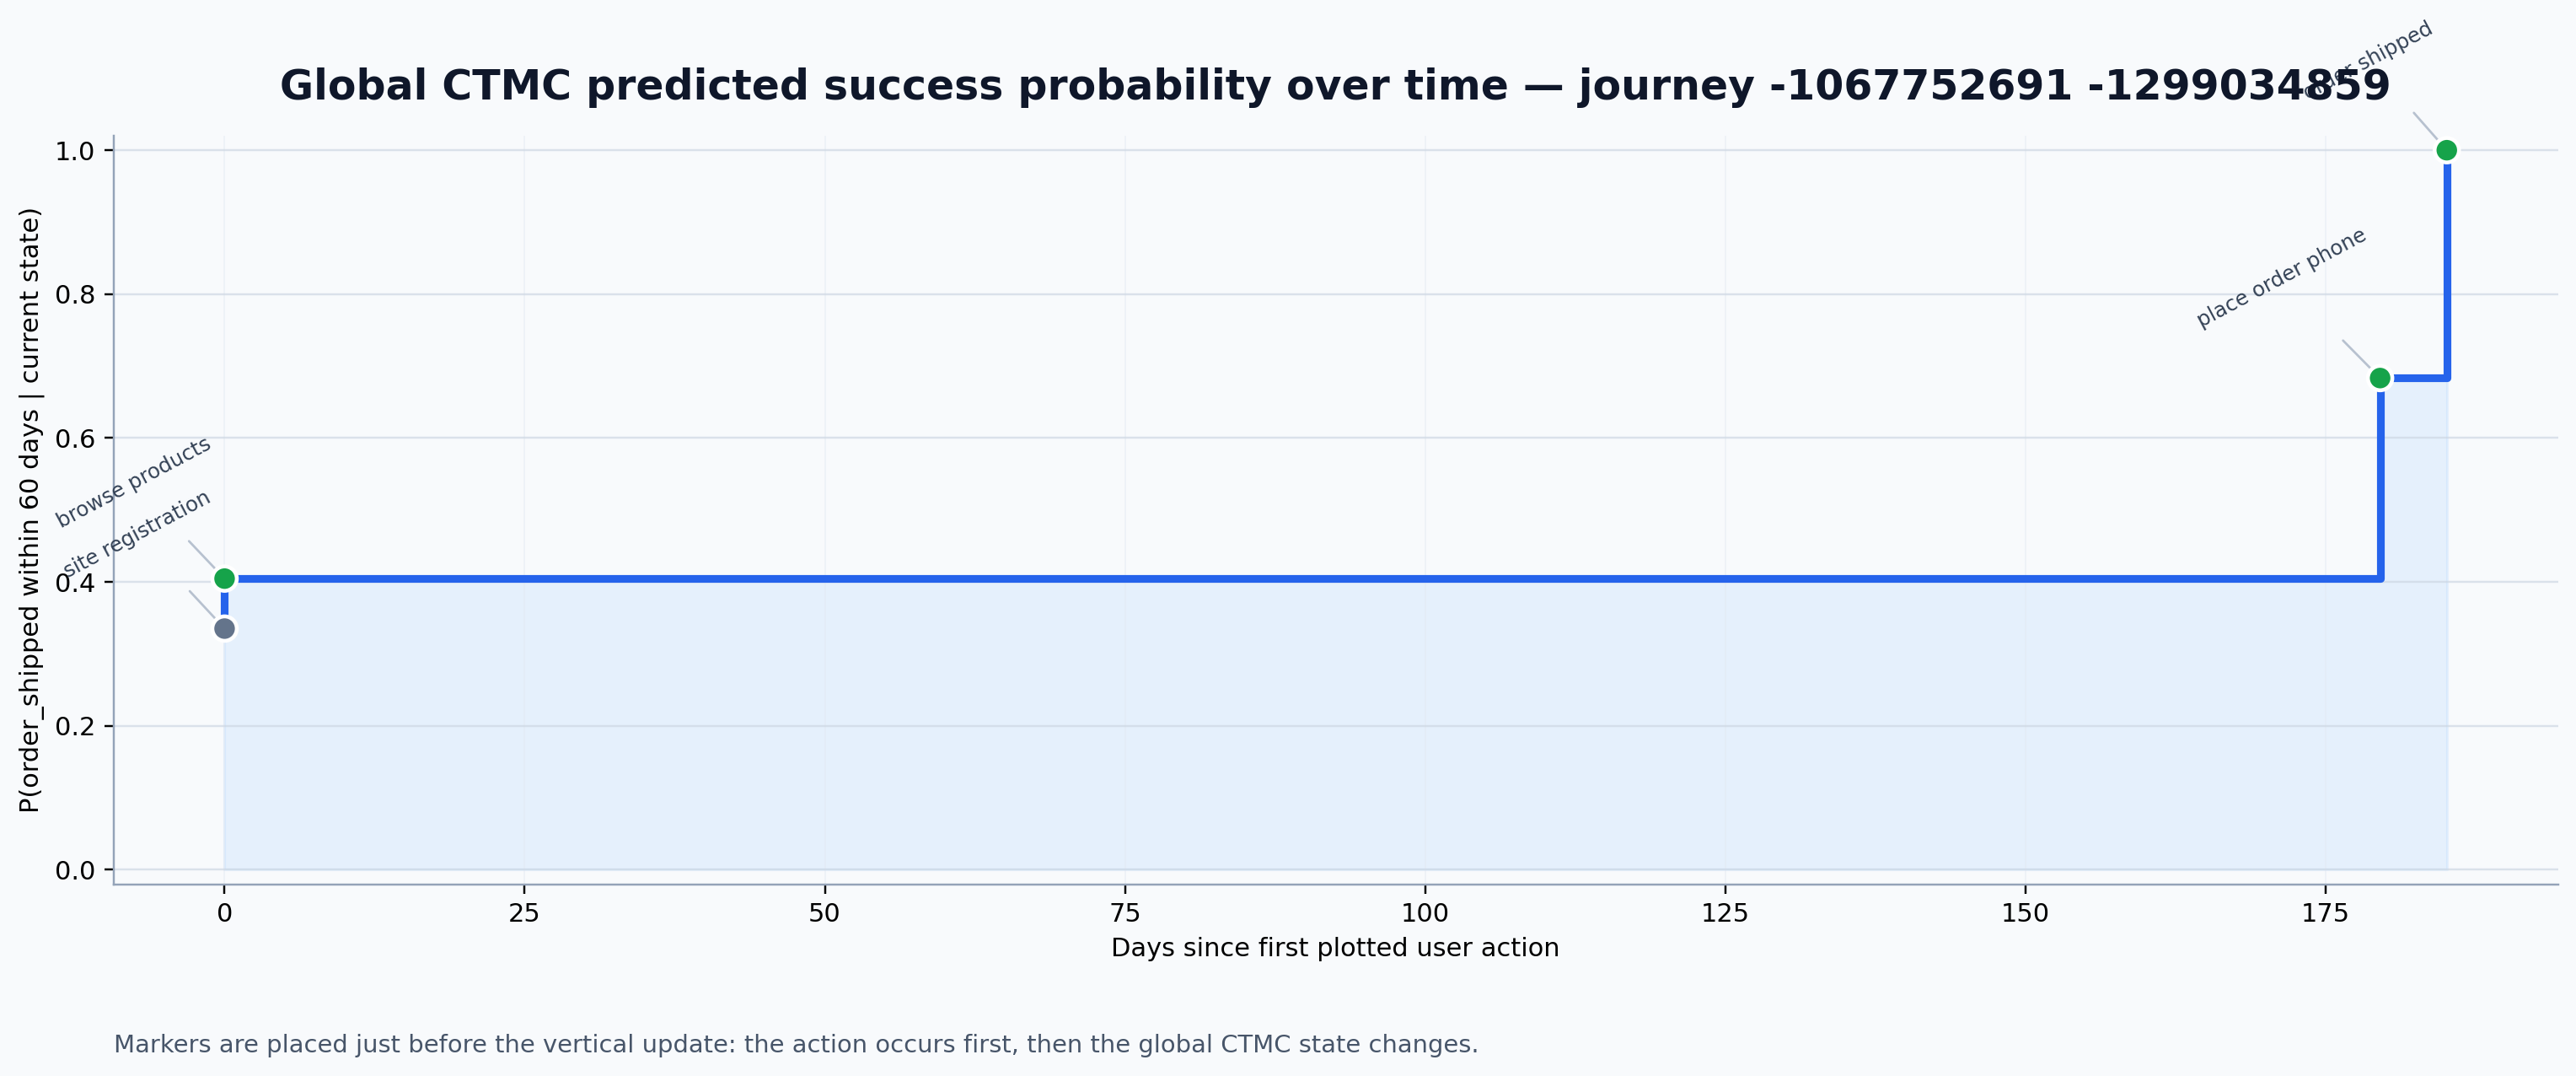

In [5]:
# Use customer-action events, including the success state, so every plotted action
# is part of the global CTMC state space.
journey_plot_events = data.events(
    max_journeys=MAX_JOURNEYS,
    customer_actions_only=True,
    include_success=True,
)
journey_plot_events["state_probability"] = global_ctmc.absorption_probability(
    journey_plot_events["ed_id"].to_numpy(),
    success_state=SUCCESS_STATE,
    horizon_seconds=60 * 24 * 60 * 60,
)

# Pick an illustrative journey automatically: enough user actions to show a path,
# and a visible probability range so the plot is not flat.
journey_candidates = (
    journey_plot_events
    .groupby("id")
    .agg(
        n_actions=("ed_id", "size"),
        p_min=("state_probability", "min"),
        p_max=("state_probability", "max"),
        reached_success=("ed_id", lambda s: bool((s == SUCCESS_STATE).any())),
    )
    .assign(p_range=lambda d: d["p_max"] - d["p_min"])
    .query("n_actions >= 4")
    .sort_values(["reached_success", "p_range", "n_actions"], ascending=[False, False, True])
)

JOURNEY_ID_FOR_PLOT = journey_candidates.index[0]
journey_probability_path = plot_journey_success_probability_over_time(
    journey_plot_events,
    global_ctmc,
    RESULTS_DIR / "ctmc_global_single_journey_probability_path.png",
    event_defs=event_defs,
    journey_id=JOURNEY_ID_FOR_PLOT,
    customer_states=customer_states,
    success_state=SUCCESS_STATE,
    horizon_days=60,
)

display(journey_probability_path)
display(Image(filename=str(RESULTS_DIR / "ctmc_global_single_journey_probability_path.png")))

## Old Baseline 2: Clustered CTMC

This is the retained segmented CTMC baseline. Set `USE_SPECTRAL_CLUSTERING = True` in the first code cell to compare spectral clustering against KMeans.

,cluster,n_journeys
0,0,7324
1,1,58797
2,2,22527


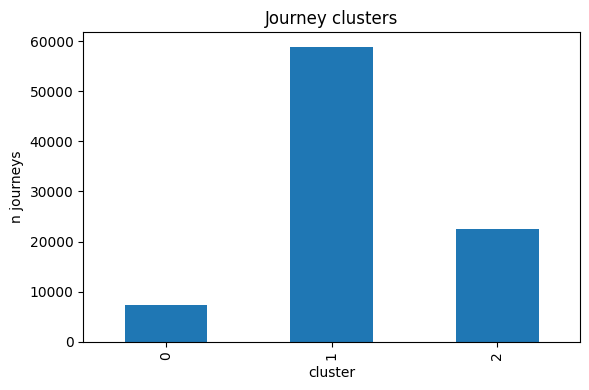

In [6]:
clustered = ClusteredCTMC(
    n_clusters=N_CLUSTERS,
    random_state=42,
    use_spectral_clustering=USE_SPECTRAL_CLUSTERING,
).fit(transitions)
cluster_summary = clustered.cluster_summary()
display(cluster_summary)

cluster_summary.plot.bar(x="cluster", y="n_journeys", legend=False, figsize=(6, 4))
plt.title("Journey clusters")
plt.ylabel("n journeys")
plt.tight_layout()
plt.show()

features = clustered.feature_builder.transform(transitions)

## New Model 1: Timeout-Absorbing CTMC

This augments the CTMC state space with an absorbing failure state. It estimates competing rates to success and failure, then solves for `P(absorb in success before failure)`.

In [7]:
timeout_ctmc = TimeoutAbsorbingCTMC().fit(timeout_transitions)
timeout_probs_by_state = pd.DataFrame({
    "state": timeout_ctmc.states_,
    "p_success_before_timeout_failure": timeout_ctmc.predict_success_probability(timeout_ctmc.states_),
}).sort_values("p_success_before_timeout_failure", ascending=False)
display(timeout_probs_by_state)

,state,p_success_before_timeout_failure
14,28,1.000000
7,8,0.581516
6,7,0.548851
10,18,0.478226
5,6,0.295282
4,5,0.273245
9,11,0.264243
8,10,0.262059
3,4,0.256465
2,3,0.222239


## Timeout-Absorbing CTMC State-Space Graph

This is the more interpretable state-space graph for our final CTMC framing: ordinary customer-action states can flow either toward order_shipped or into the explicit 60-day inactivity failure absorbing state. Edge thickness reflects the fitted transition rate, and the two terminal outcomes are colored separately.


,from_state,to_state,rate
85,10,4,1.443001e-03
86,10,5,7.215007e-04
91,11,5,9.080752e-06
90,11,4,8.720573e-06
21,3,19,6.378999e-06
68,7,8,5.809477e-06
84,8,28,1.495694e-06
40,5,4,1.460512e-06
41,5,6,1.425606e-06
76,8,4,1.276554e-06


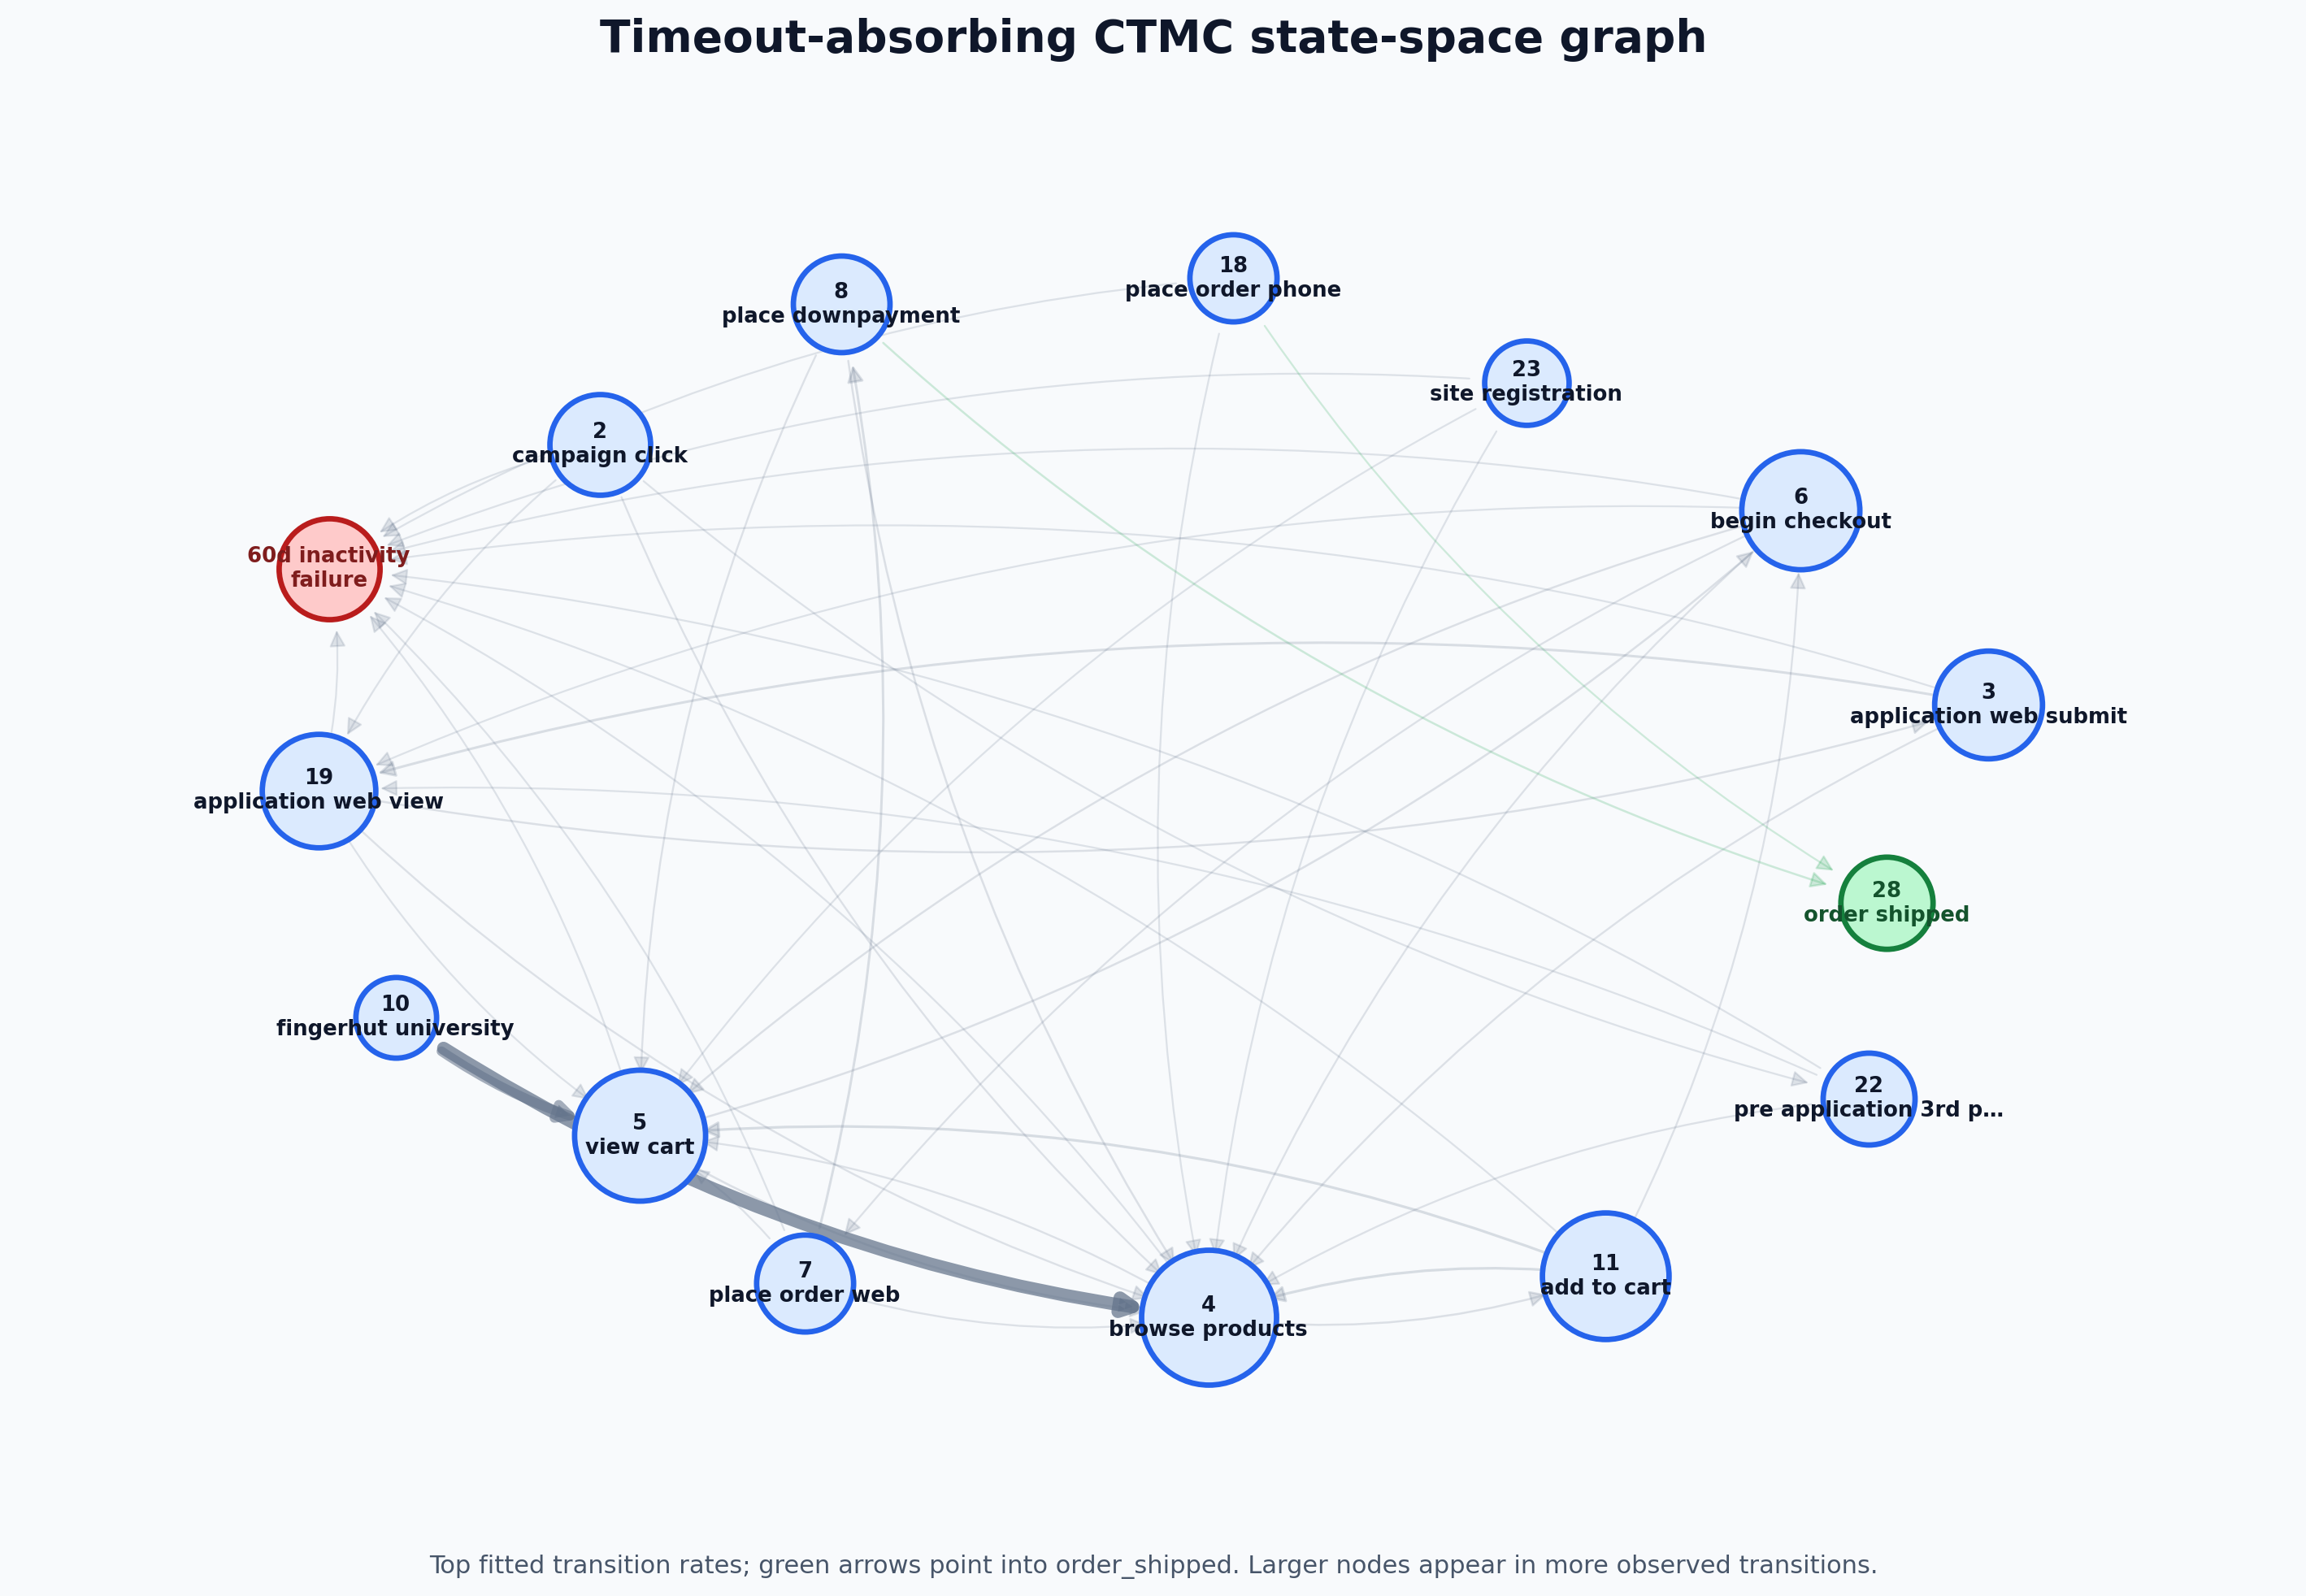

In [8]:
timeout_state_space_graph_path = RESULTS_DIR / "ctmc_timeout_absorbing_state_space_graph.png"
timeout_state_space_edges = plot_aesthetic_state_space_graph(
    timeout_ctmc,
    timeout_state_space_graph_path,
    event_defs=event_defs,
    n_edges=44,
    success_state=SUCCESS_STATE,
    title="Timeout-absorbing CTMC state-space graph",
)
display(timeout_state_space_edges.head(16))
display(Image(filename=str(timeout_state_space_graph_path)))

## CTMC Visualization Toolkit: Topology, Sample Paths, and Distribution Flow

These plots look at the fitted CTMC from three complementary angles:

- **Topology:** which states are connected by the largest fitted rates in the generator matrix $Q$.
- **Sample paths:** what one simulated continuous-time customer trajectory looks like.
- **Distribution flow:** how the full probability distribution over states changes over time from a chosen start state.


In [9]:
import numpy as np
import seaborn as sns

SECONDS_PER_DAY = 24 * 60 * 60
EVENT_NAME_BY_ID = {
    int(row["event_definition_id"]): str(row["event_name"])
    for _, row in event_defs.iterrows()
}


def state_label(state: int) -> str:
    state = int(state)
    if state == SUCCESS_STATE:
        return f"{state}: order_shipped"
    if state == FAILURE_STATE:
        return "timeout / failure"
    return f"{state}: {EVENT_NAME_BY_ID.get(state, str(state))}"


def short_state_label(state: int, max_chars: int = 28) -> str:
    label = state_label(state).replace("_", " ")
    return label if len(label) <= max_chars else label[: max_chars - 1] + "…"


def top_q_edges(model, n_edges: int = 32) -> pd.DataFrame:
    """Return largest off-diagonal generator entries, reported per day."""
    edges = model.top_rates(n_edges).copy()
    edges["rate_per_day"] = edges["rate"] * SECONDS_PER_DAY
    edges["from_label"] = edges["from_state"].map(state_label)
    edges["to_label"] = edges["to_state"].map(state_label)
    return edges


def plot_graphviz_q_topology(model, output_path: Path, n_edges: int = 32):
    """Render a directed weighted state-transition diagram using Graphviz.

    Edge labels show fitted generator rates in jumps/day. These are not
    empirical transition probabilities; they are entries of the CTMC generator.
    """
    edges = top_q_edges(model, n_edges=n_edges)
    try:
        from graphviz import Digraph

        dot = Digraph("ctmc_topology", graph_attr={"rankdir": "LR", "bgcolor": "white"})
        dot.attr("node", shape="box", style="rounded,filled", fontname="Helvetica")
        dot.attr("edge", fontname="Helvetica", fontsize="9")

        states = sorted(set(edges["from_state"]).union(edges["to_state"]))
        for state in states:
            if state == SUCCESS_STATE:
                fill = "#bbf7d0"
            elif state == FAILURE_STATE:
                fill = "#fecaca"
            else:
                fill = "#dbeafe"
            dot.node(str(state), short_state_label(state), fillcolor=fill)

        max_rate = max(edges["rate_per_day"].max(), 1e-12)
        for _, row in edges.iterrows():
            rate_day = float(row["rate_per_day"])
            penwidth = 0.8 + 4.0 * np.sqrt(rate_day / max_rate)
            color = "#16a34a" if int(row["to_state"]) == SUCCESS_STATE else "#475569"
            dot.edge(
                str(int(row["from_state"])),
                str(int(row["to_state"])),
                label=f"q={rate_day:.2g}/day",
                color=color,
                penwidth=f"{penwidth:.2f}",
            )

        output_path.parent.mkdir(parents=True, exist_ok=True)
        rendered = Path(dot.render(str(output_path.with_suffix("")), format="png", cleanup=True))
        display(Image(filename=str(rendered)))
        return edges
    except Exception as exc:
        print(f"Graphviz render failed; use the NetworkX plot below. Reason: {exc}")
        return edges


def plot_networkx_q_topology(model, output_path: Path, n_edges: int = 32):
    """Render the same top generator edges using NetworkX + Matplotlib."""
    import networkx as nx

    edges = top_q_edges(model, n_edges=n_edges)
    graph = nx.DiGraph()
    for _, row in edges.iterrows():
        graph.add_edge(int(row["from_state"]), int(row["to_state"]), weight=float(row["rate_per_day"]))

    pos = nx.spring_layout(graph, seed=148, weight="weight", k=1.25)
    node_colors = [
        "#bbf7d0" if node == SUCCESS_STATE else "#fecaca" if node == FAILURE_STATE else "#dbeafe"
        for node in graph.nodes
    ]
    node_labels = {node: short_state_label(node, max_chars=24) for node in graph.nodes}
    weights = np.array([graph[u][v]["weight"] for u, v in graph.edges], dtype=float)
    widths = 0.8 + 4.0 * np.sqrt(weights / max(weights.max(), 1e-12))

    fig, ax = plt.subplots(figsize=(14, 9), facecolor="white")
    nx.draw_networkx_nodes(graph, pos, node_color=node_colors, edgecolors="#334155", linewidths=1.2, node_size=2300, ax=ax)
    nx.draw_networkx_labels(graph, pos, labels=node_labels, font_size=8, font_weight="semibold", ax=ax)
    nx.draw_networkx_edges(
        graph,
        pos,
        width=widths,
        edge_color="#64748b",
        alpha=0.62,
        arrows=True,
        arrowsize=16,
        connectionstyle="arc3,rad=0.10",
        ax=ax,
    )
    edge_labels = {(u, v): f"{graph[u][v]['weight']:.2g}/d" for u, v in graph.edges}
    nx.draw_networkx_edge_labels(graph, pos, edge_labels=edge_labels, font_size=7, label_pos=0.55, ax=ax)

    ax.set_title("Top fitted CTMC transition rates from Q", fontsize=16, fontweight="bold")
    ax.set_axis_off()
    fig.tight_layout()
    output_path.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(output_path, dpi=220, bbox_inches="tight")
    plt.close(fig)
    display(Image(filename=str(output_path)))
    return edges


### 1. State-transition diagrams from the fitted $Q$ matrix

The next two plots show the largest off-diagonal rates in the fitted generator matrix. Edge labels are rates per day, not transition probabilities. If the Graphviz executable is not available on the local machine, the NetworkX plot still renders the same topology.


Graphviz render failed; use the NetworkX plot below. Reason: failed to execute WindowsPath('dot'), make sure the Graphviz executables are on your systems' PATH


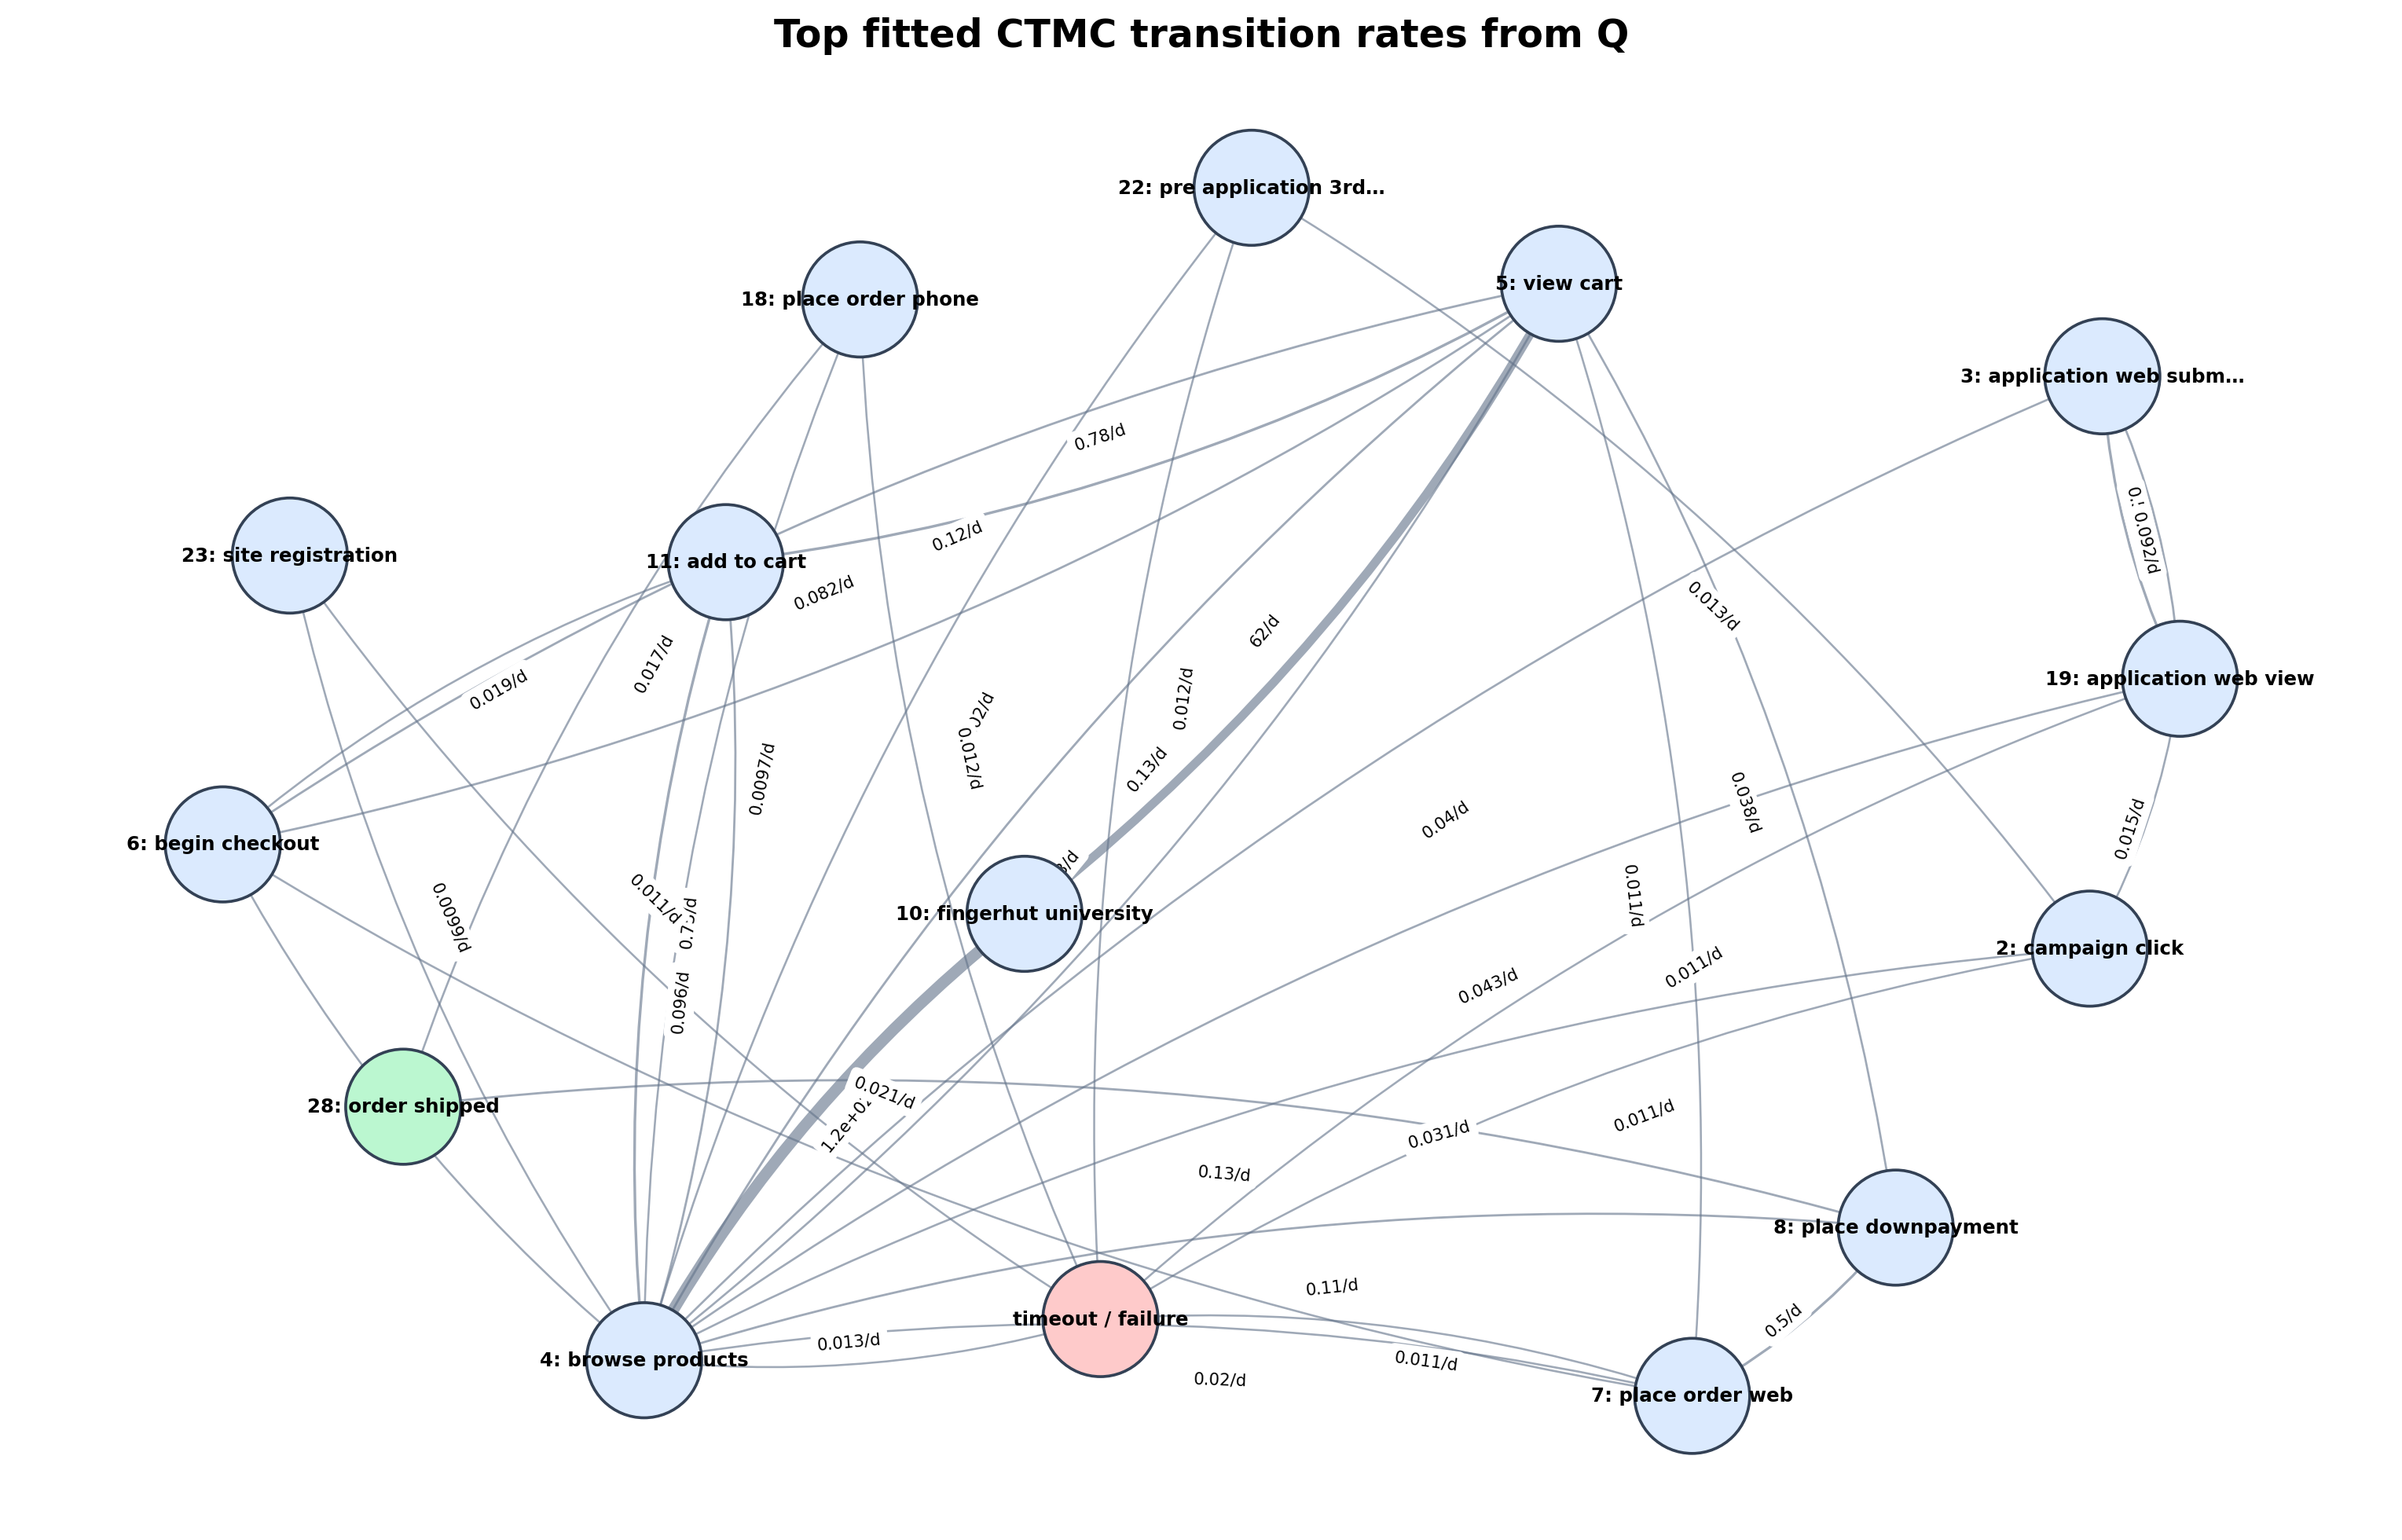

,from_label,to_label,rate_per_day
85,10: fingerhut_university,4: browse_products,124.675325
86,10: fingerhut_university,5: view_cart,62.337662
91,11: add_to_cart,5: view_cart,0.784577
90,11: add_to_cart,4: browse_products,0.753458
21,3: application_web_submit,19: application_web_view,0.551146
68,7: place_order_web,8: place_downpayment,0.501939
84,8: place_downpayment,28: order_shipped,0.129228
40,5: view_cart,4: browse_products,0.126188
41,5: view_cart,6: begin_checkout,0.123172
76,8: place_downpayment,4: browse_products,0.110294


In [10]:
graphviz_edges = plot_graphviz_q_topology(
    timeout_ctmc,
    RESULTS_DIR / "ctmc_graphviz_timeout_topology.png",
    n_edges=36,
)

networkx_edges = plot_networkx_q_topology(
    timeout_ctmc,
    RESULTS_DIR / "ctmc_networkx_timeout_topology.png",
    n_edges=36,
)

display(networkx_edges[["from_label", "to_label", "rate_per_day"]].head(12))


### 2. Simulated CTMC trajectory trace

This simulates one realization of the fitted timeout-aware CTMC. The horizontal pieces show holding times; the vertical jumps show state changes.


In [11]:
import plotly.graph_objects as go


def simulate_ctmc_trajectory(model, start_state: int, horizon_days: float = 60, seed: int = 148) -> pd.DataFrame:
    rng = np.random.default_rng(seed)
    q = model.Q_.copy()
    horizon_seconds = horizon_days * SECONDS_PER_DAY
    current_state = int(start_state)
    elapsed = 0.0
    rows = []

    while elapsed < horizon_seconds:
        if current_state not in q.index:
            rows.append({
                "start_day": elapsed / SECONDS_PER_DAY,
                "end_day": horizon_days,
                "state": current_state,
                "next_state": current_state,
                "holding_days": horizon_days - elapsed / SECONDS_PER_DAY,
                "absorbing_or_unknown": True,
            })
            break

        row = q.loc[current_state].astype(float).copy()
        exit_rate = float(-row.loc[current_state])
        if exit_rate <= 0:
            rows.append({
                "start_day": elapsed / SECONDS_PER_DAY,
                "end_day": horizon_days,
                "state": current_state,
                "next_state": current_state,
                "holding_days": horizon_days - elapsed / SECONDS_PER_DAY,
                "absorbing_or_unknown": True,
            })
            break

        wait = float(rng.exponential(1.0 / exit_rate))
        jump_time = elapsed + wait
        end_time = min(jump_time, horizon_seconds)

        outgoing = row.clip(lower=0.0)
        outgoing.loc[current_state] = 0.0
        probs = outgoing / outgoing.sum()
        next_state = int(rng.choice(probs.index.to_numpy(dtype=int), p=probs.to_numpy(dtype=float)))

        rows.append({
            "start_day": elapsed / SECONDS_PER_DAY,
            "end_day": end_time / SECONDS_PER_DAY,
            "state": current_state,
            "next_state": next_state if jump_time <= horizon_seconds else current_state,
            "holding_days": (end_time - elapsed) / SECONDS_PER_DAY,
            "absorbing_or_unknown": False,
        })

        if jump_time > horizon_seconds:
            break
        elapsed = jump_time
        current_state = next_state

    path = pd.DataFrame(rows)
    path["state_label"] = path["state"].map(state_label)
    path["next_state_label"] = path["next_state"].map(state_label)
    return path


def plotly_ctmc_trajectory(path: pd.DataFrame, title: str = "Simulated CTMC trajectory"):
    states_in_path = list(dict.fromkeys(path["state"].to_list() + path["next_state"].to_list()))
    y_lookup = {state: idx for idx, state in enumerate(states_in_path)}

    x = path["start_day"].to_list() + [float(path["end_day"].iloc[-1])]
    y_states = path["state"].to_list() + [int(path["next_state"].iloc[-1])]
    y = [y_lookup[state] for state in y_states]

    hover_text = [
        f"state: {state_label(row.state)}<br>held for: {row.holding_days:.2f} days<br>next: {state_label(row.next_state)}"
        for row in path.itertuples(index=False)
    ] + [f"state: {state_label(y_states[-1])}"]

    fig = go.Figure()
    fig.add_trace(go.Scatter(
        x=x,
        y=y,
        mode="lines+markers",
        line={"shape": "hv", "width": 4, "color": "#2563eb"},
        marker={"size": 9, "color": "#0f172a"},
        text=hover_text,
        hovertemplate="day %{x:.2f}<br>%{text}<extra></extra>",
        name="simulated state",
    ))
    fig.update_layout(
        title=title,
        template="plotly_white",
        width=1100,
        height=520,
        xaxis_title="time since start of simulation (days)",
        yaxis={
            "title": "CTMC state",
            "tickmode": "array",
            "tickvals": list(y_lookup.values()),
            "ticktext": [short_state_label(state, max_chars=38) for state in states_in_path],
        },
        margin={"l": 180, "r": 30, "t": 70, "b": 60},
    )
    return fig


VIS_START_STATE = 4 if 4 in timeout_ctmc.states_ else next(
    state for state in timeout_ctmc.states_ if state not in {SUCCESS_STATE, FAILURE_STATE}
)
trajectory = simulate_ctmc_trajectory(timeout_ctmc, start_state=VIS_START_STATE, horizon_days=60, seed=148)
display(trajectory.head(20))
trajectory_fig = plotly_ctmc_trajectory(
    trajectory,
    title=f"One simulated timeout-aware CTMC trajectory starting from {state_label(VIS_START_STATE)}",
)
trajectory_fig.show()
trajectory_fig.write_html(RESULTS_DIR / "ctmc_simulated_trajectory.html")


,start_day,end_day,state,next_state,holding_days,absorbing_or_unknown,state_label,next_state_label
0,0.000000,8.179287,4,11,8.179287,False,4: browse_products,11: add_to_cart
1,8.179287,9.150740,11,5,0.971454,False,11: add_to_cart,5: view_cart
2,9.150740,11.827009,5,6,2.676269,False,5: view_cart,6: begin_checkout
3,11.827009,27.678215,6,5,15.851206,False,6: begin_checkout,5: view_cart
4,27.678215,36.775834,5,6,9.097619,False,5: view_cart,6: begin_checkout
5,36.775834,43.004888,6,28,6.229054,False,6: begin_checkout,28: order_shipped
6,43.004888,60.000000,28,28,16.995112,True,28: order_shipped,28: order_shipped


### 3. Probability distribution over states through time

Starting from a chosen customer-action state, this computes $p_0 e^{Qt}$ over a grid of times. The heatmap shows where probability mass flows; the stacked area chart shows the same evolution as cumulative mass.


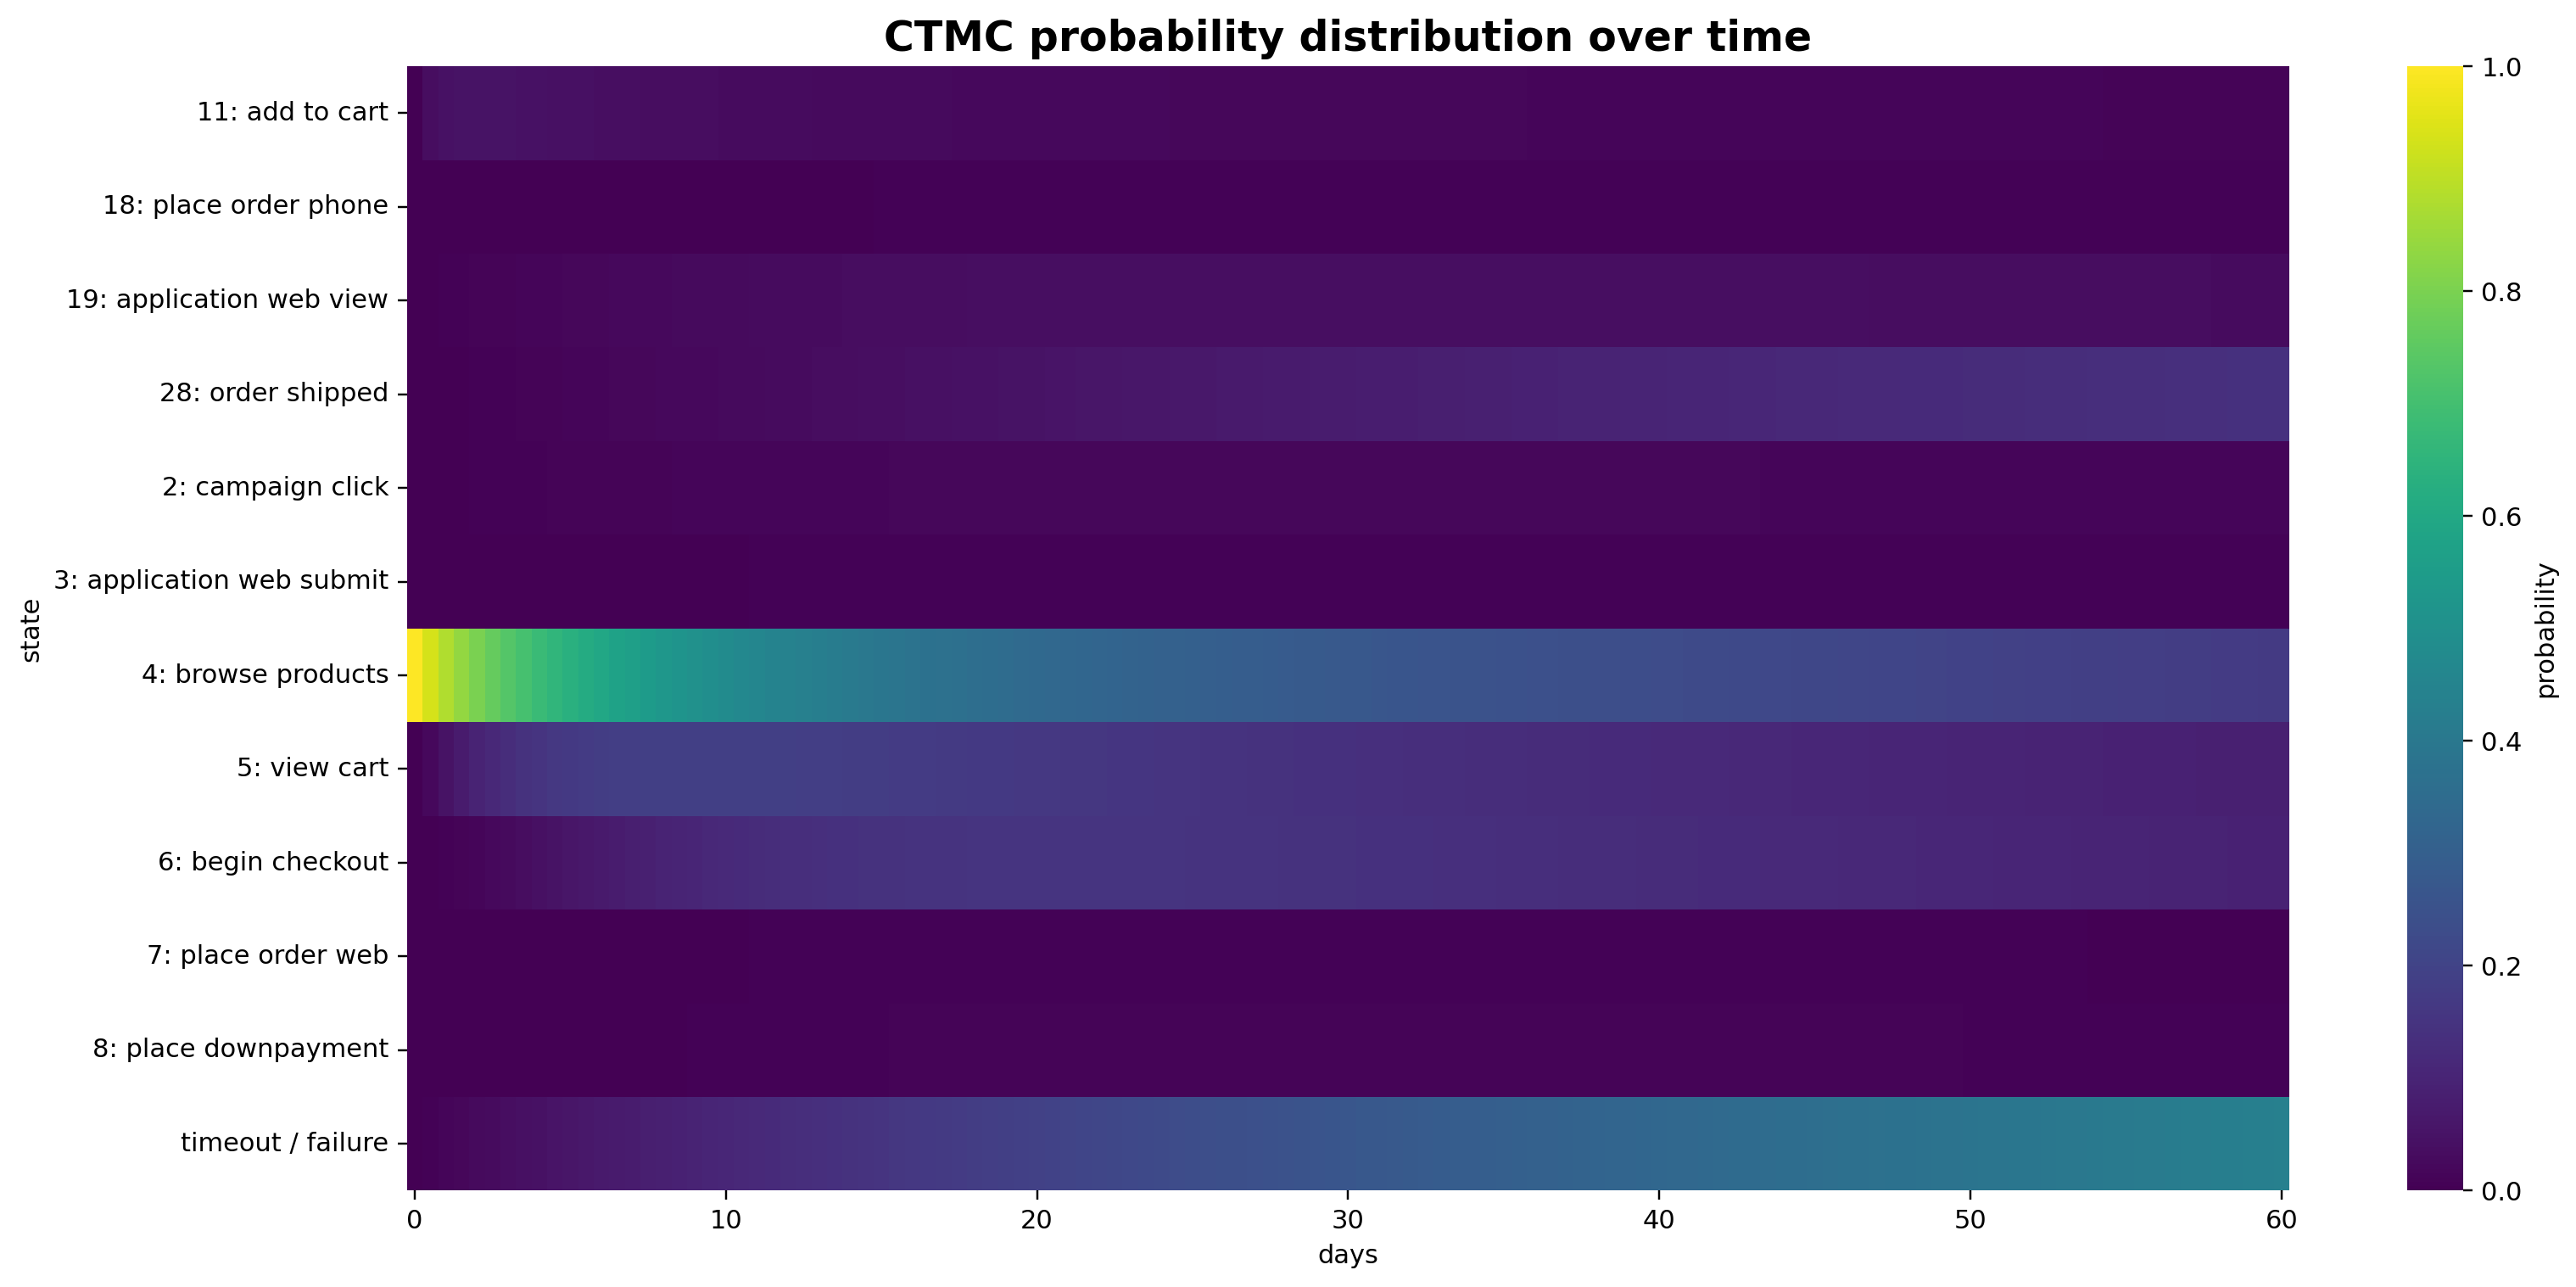

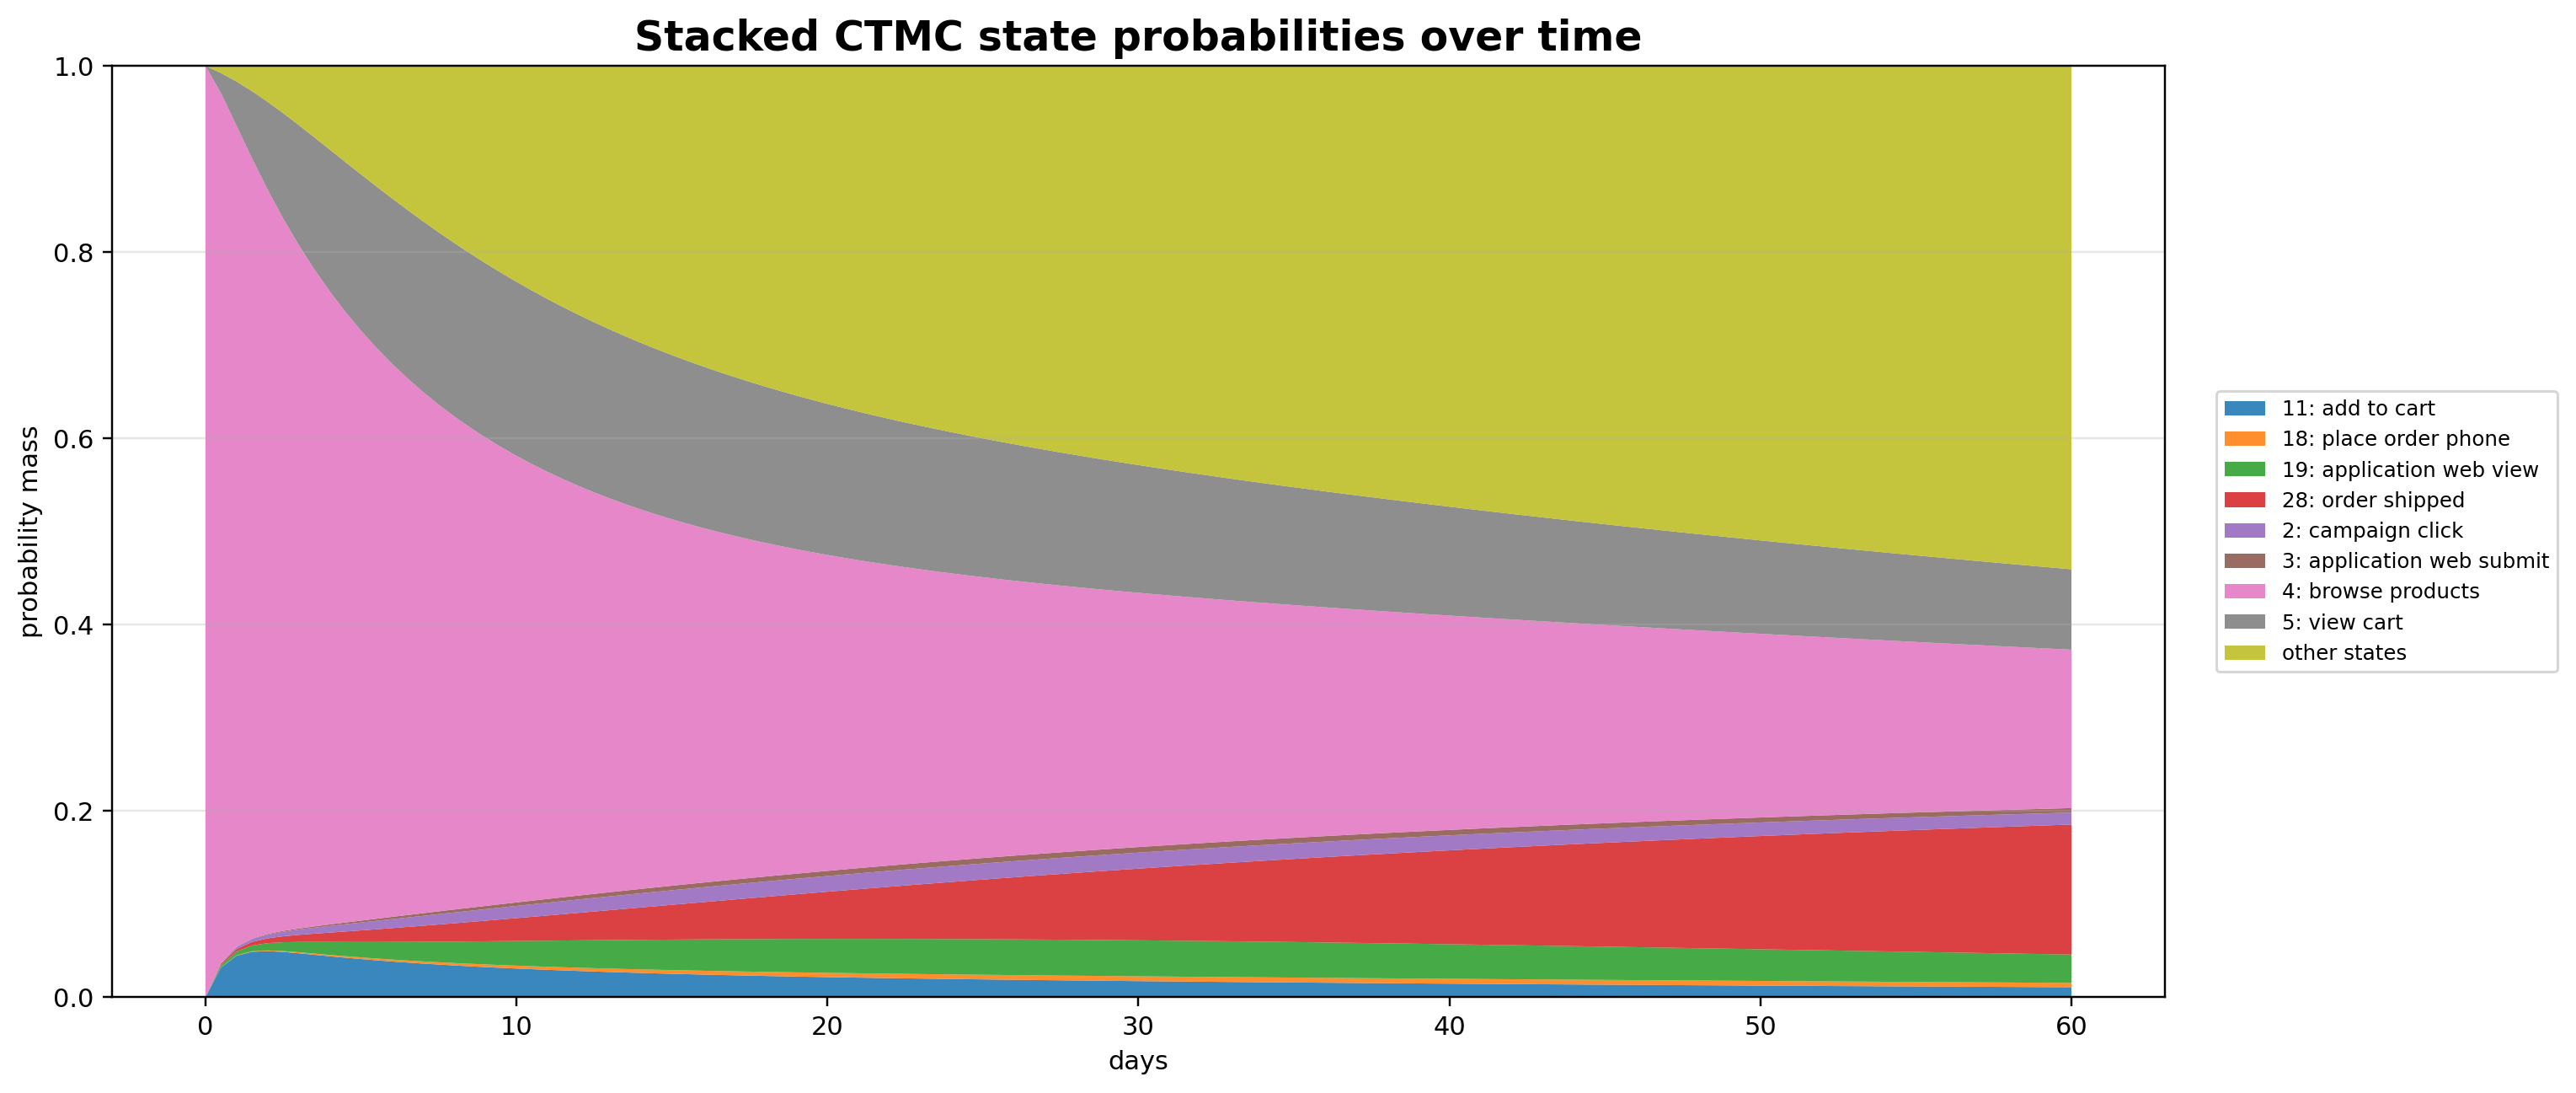

,day,state,state_label,probability
3,0.0,4,4: browse products,1.000000
0,0.0,-1,timeout / failure,0.000000
1,0.0,2,2: campaign click,0.000000
18,0.5,4,4: browse products,0.933710
24,0.5,11,11: add to cart,0.031930
19,0.5,5,5: view cart,0.021709
33,1.0,4,4: browse products,0.881449
34,1.0,5,5: view cart,0.047479
39,1.0,11,11: add to cart,0.044617
48,1.5,4,4: browse products,0.837529


In [12]:
from scipy.linalg import expm


def ctmc_distribution_over_time(model, start_state: int, horizon_days: float = 60, n_grid: int = 121) -> pd.DataFrame:
    q = model.Q_.copy()
    states = list(q.index)
    if start_state not in states:
        raise ValueError(f"start_state={start_state} is not in the CTMC state space")

    q_values = q.to_numpy(dtype=float)
    start_idx = states.index(start_state)
    p0 = np.zeros(len(states), dtype=float)
    p0[start_idx] = 1.0

    rows = []
    for day in np.linspace(0, horizon_days, n_grid):
        probs = p0 @ expm(q_values * day * SECONDS_PER_DAY)
        for state, prob in zip(states, probs):
            rows.append({
                "day": float(day),
                "state": int(state),
                "state_label": short_state_label(state, max_chars=34),
                "probability": float(np.clip(prob, 0.0, 1.0)),
            })
    return pd.DataFrame(rows)


def plot_distribution_heatmap(dist: pd.DataFrame, output_path: Path, max_states: int = 12):
    important_states = (
        dist.groupby("state")["probability"]
        .max()
        .sort_values(ascending=False)
        .head(max_states)
        .index
        .to_list()
    )
    for state in [SUCCESS_STATE, FAILURE_STATE]:
        if state in dist["state"].unique() and state not in important_states:
            important_states.append(state)

    heat = (
        dist[dist["state"].isin(important_states)]
        .pivot_table(index="state_label", columns="day", values="probability", aggfunc="mean")
        .fillna(0.0)
    )

    fig, ax = plt.subplots(figsize=(15, 7), facecolor="white")
    sns.heatmap(heat, cmap="viridis", vmin=0, vmax=max(heat.max().max(), 1e-9), ax=ax, cbar_kws={"label": "probability"})
    ax.set_title("CTMC probability distribution over time", fontsize=16, fontweight="bold")
    ax.set_xlabel("days")
    ax.set_ylabel("state")
    tick_positions = np.linspace(0, heat.shape[1] - 1, 7).astype(int)
    ax.set_xticks(tick_positions + 0.5)
    ax.set_xticklabels([f"{float(heat.columns[i]):.0f}" for i in tick_positions], rotation=0)
    fig.tight_layout()
    output_path.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(output_path, dpi=220, bbox_inches="tight")
    plt.close(fig)
    display(Image(filename=str(output_path)))
    return heat


def plot_distribution_stacked_area(dist: pd.DataFrame, output_path: Path, selected_state_labels: list[str]):
    selected = dist[dist["state_label"].isin(selected_state_labels)].copy()
    wide = selected.pivot_table(index="day", columns="state_label", values="probability", aggfunc="mean").fillna(0.0)
    wide["other states"] = np.clip(1.0 - wide.sum(axis=1), 0.0, 1.0)

    fig, ax = plt.subplots(figsize=(14, 6), facecolor="white")
    ax.stackplot(wide.index.to_numpy(), [wide[col].to_numpy() for col in wide.columns], labels=wide.columns, alpha=0.88)
    ax.set_title("Stacked CTMC state probabilities over time", fontsize=16, fontweight="bold")
    ax.set_xlabel("days")
    ax.set_ylabel("probability mass")
    ax.set_ylim(0, 1)
    ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), fontsize=8)
    ax.grid(axis="y", alpha=0.3)
    fig.tight_layout()
    output_path.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(output_path, dpi=220, bbox_inches="tight")
    plt.close(fig)
    display(Image(filename=str(output_path)))


dist_over_time = ctmc_distribution_over_time(timeout_ctmc, start_state=VIS_START_STATE, horizon_days=60, n_grid=121)
heat = plot_distribution_heatmap(
    dist_over_time,
    RESULTS_DIR / "ctmc_probability_distribution_heatmap.png",
    max_states=12,
)
plot_distribution_stacked_area(
    dist_over_time,
    RESULTS_DIR / "ctmc_probability_distribution_stacked_area.png",
    selected_state_labels=heat.index.to_list()[:8],
)

display(
    dist_over_time
    .query("state in @timeout_ctmc.states_")
    .sort_values(["day", "probability"], ascending=[True, False])
    .groupby("day")
    .head(3)
    .head(15)
)


## Interactive Timeout-Absorbing Probability Path

The static journey plot above uses the old global CTMC success-within-horizon score. The interactive Plotly version below uses the timeout-absorbing CTMC instead, so the y-axis is the probability of reaching order_shipped before the explicit 60-day inactivity-failure state. Each marker is labeled by state id and, on hover, the action name from Event Definitions.csv.


In [13]:
# Reuse the same candidate-selection idea, but score with the timeout-absorbing CTMC.
timeout_journey_plot_events = data.events(
    max_journeys=MAX_JOURNEYS,
    customer_actions_only=True,
    include_success=True,
)
timeout_journey_plot_events["timeout_success_probability"] = timeout_ctmc.predict_success_probability(
    timeout_journey_plot_events["ed_id"].to_numpy(),
    success_state=SUCCESS_STATE,
    horizon_seconds=60 * 24 * 60 * 60,
)

timeout_journey_candidates = (
    timeout_journey_plot_events
    .groupby("id")
    .agg(
        n_actions=("ed_id", "size"),
        p_min=("timeout_success_probability", "min"),
        p_max=("timeout_success_probability", "max"),
        reached_success=("ed_id", lambda s: bool((s == SUCCESS_STATE).any())),
    )
    .assign(p_range=lambda d: d["p_max"] - d["p_min"])
    .query("n_actions >= 4")
    .sort_values(["reached_success", "p_range", "n_actions"], ascending=[False, False, True])
)

TIMEOUT_JOURNEY_ID_FOR_PLOT = timeout_journey_candidates.index[0]
timeout_probability_fig, timeout_probability_path = plotly_timeout_probability_over_time(
    timeout_journey_plot_events,
    timeout_ctmc,
    event_defs=event_defs,
    journey_id=TIMEOUT_JOURNEY_ID_FOR_PLOT,
    customer_states=customer_states,
    success_state=SUCCESS_STATE,
    horizon_days=60,
)

display(timeout_probability_path)
timeout_probability_fig.show()

,id,event_timestamp,elapsed_days,ed_id,action_name,state_action_label,success_probability,delta_probability,direction
0,-1082482231 691013218,2021-05-31 06:00:00+00:00,0.000000,2,campaign_click,2 — campaign click,0.206190,0.000000,unchanged
1,-1082482231 691013218,2021-05-31 06:00:00+00:00,0.000000,22,pre_application_3rd_party_affiliates,22 — pre application 3rd party affiliates,0.180481,-0.025708,decrease
2,-1082482231 691013218,2021-06-22 13:35:41+00:00,22.316447,18,place_order_phone,18 — place order phone,0.478226,0.297744,increase
3,-1082482231 691013218,2021-06-26 00:00:00+00:00,25.750000,28,order_shipped,28 — order shipped,1.000000,0.521774,increase


## New Model 2: Empirical Semi-Markov Timeout Model

This model does not assume exponential waiting times. It uses observed outgoing transition samples and treats waits over 60 days as failure. It estimates the recursive probability of eventually reaching success before a timeout.

In [14]:
semi_markov = SemiMarkovTimeoutModel().fit(timeout_transitions)
semi_probs_by_state = pd.DataFrame({
    "state": semi_markov.states_,
    "p_success_before_timeout_failure": semi_markov.predict_success_probability(semi_markov.states_),
}).sort_values("p_success_before_timeout_failure", ascending=False)
display(semi_probs_by_state)

KeyboardInterrupt: 

## Diagnostic Comparison on Resolved Journeys

This joins model scores to resolved labels. It is diagnostic rather than a perfect offline validation because these features are built from completed journeys. For Kaggle-style evaluation, prefer open/test-prefix submissions.

In [15]:
labels = data.load_binary_labels()
eval_df = features.merge(labels, on="id", how="inner")

predictions = {
    "global_ctmc_old_target": global_ctmc.absorption_probability(eval_df["current_state"]),
    "clustered_ctmc_old_target": clustered.predict_success_probability(eval_df, fallback_model=global_ctmc),
    "timeout_absorbing_ctmc": timeout_ctmc.predict_success_probability(eval_df["current_state"]),
    #"semi_markov_timeout": semi_markov.predict_success_probability(eval_df["current_state"]),
}

y = eval_df["label"].astype(int).to_numpy()
rows = []
for name, probs in predictions.items():
    probs = pd.Series(probs).clip(1e-6, 1 - 1e-6).to_numpy()
    rows.append({
        "model": name,
        "brier_score": brier_score_loss(y, probs),
        "log_loss": log_loss(y, probs, labels=[0, 1]),
        "roc_auc": roc_auc_score(y, probs),
        "average_precision": average_precision_score(y, probs),
        "mean_prob": probs.mean(),
    })

comparison = pd.DataFrame(rows).sort_values("brier_score")
comparison.to_csv(RESULTS_DIR / "ctmc_timeout_model_comparison.csv", index=False)
display(comparison)

,model,brier_score,log_loss,roc_auc,average_precision,mean_prob
1,clustered_ctmc_old_target,0.171869,0.512220,0.684671,0.382090,0.352683
2,timeout_absorbing_ctmc,0.174619,0.530186,0.665431,0.382231,0.257372
0,global_ctmc_old_target,0.199730,0.588932,0.648780,0.367616,0.400493


## Per-State Probability Comparison

,state,global_hit_success_60d,timeout_absorbing_success_before_failure
6,8,0.656768,0.581516
5,7,0.635748,0.548851
9,18,0.683339,0.478226
4,6,0.417938,0.295282
3,5,0.406118,0.273245
8,11,0.403690,0.264243
7,10,0.405335,0.262059
2,4,0.404626,0.256465
1,3,0.366277,0.222239
10,19,0.367795,0.221947


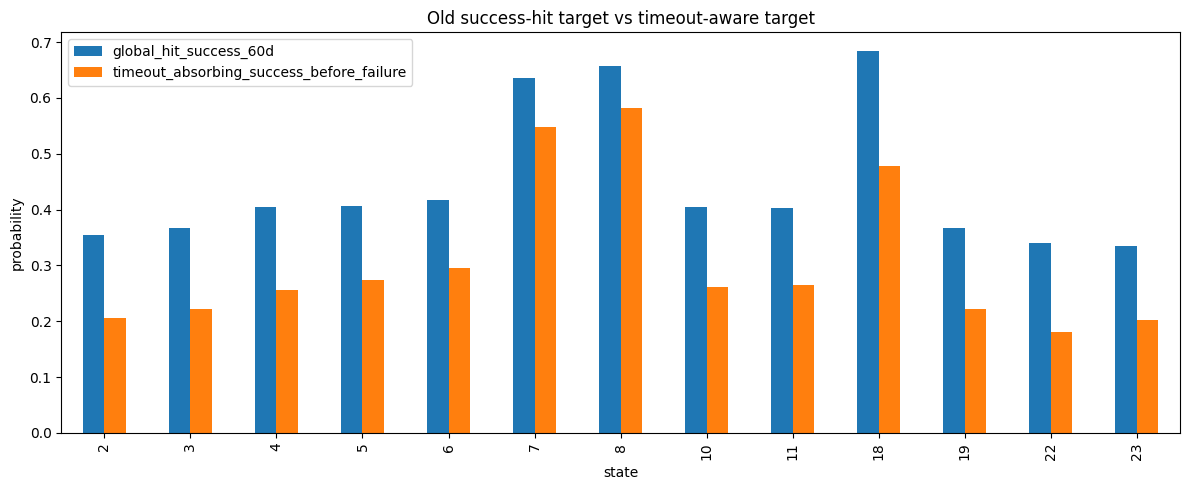

In [19]:
all_states = sorted(set(global_ctmc.states_) | set(timeout_ctmc.states_)) #| set(semi_markov.states_))
all_states = [s for s in all_states if s not in {SUCCESS_STATE, FAILURE_STATE}]
state_comparison = pd.DataFrame({
    "state": all_states,
    "global_hit_success_60d": global_ctmc.absorption_probability(all_states),
    "timeout_absorbing_success_before_failure": timeout_ctmc.predict_success_probability(all_states),
    #"semi_markov_success_before_failure": semi_markov.predict_success_probability(all_states),
})
display(state_comparison.sort_values("timeout_absorbing_success_before_failure", ascending=False))

state_comparison.set_index("state").plot.bar(figsize=(12, 5))
plt.ylabel("probability")
plt.title("Old success-hit target vs timeout-aware target")
plt.tight_layout()
plt.show()

## Submission Commands

From PowerShell, run the full retained CTMC set:

```powershell
python -m src.models.ctmc_pipeline all --no-cache
```

Run only spectral clustered CTMC:

```powershell
python -m src.models.ctmc_pipeline clustered --use-spectral-clustering --no-cache
```

## Open Journeys 2 CTMC Pipeline Outputs

The `open_journeys2_flattened_all0.csv` file is still a submission template, not labels. But the all-zero public Brier score gives the positive prevalence directly: if every prediction is 0, then Brier = mean(y), so the open_journeys2 target prevalence is about `0.04180`.

Use the Python pipeline as the source of truth, then load the generated CSVs below:

```powershell
$TEST = "data\open_journeys2.csv"
$SAMPLE = "data\open_journeys2_flattened_all0.csv"
$OUT = "results\submissions\open_journeys2"
$PREV = 0.04180

python -m src.models.ctmc_pipeline suite --test-events $TEST --sample $SAMPLE --output-dir $OUT --n-clusters 3 --max-journeys 100000 --test-prevalence $PREV
```

For CTMCs, we calibrate to this prevalence instead of downsampling the training journeys. The generator matrix estimates depend on transition counts divided by exposure time, so aggressive label-based subsampling can distort the rates we are trying to estimate.


In [ ]:
import subprocess
import sys

OPEN2_PREVALENCE = 0.04180
OPEN2_EVENTS_PATH = PROJECT_ROOT / "data" / "open_journeys2.csv"
OPEN2_SAMPLE_PATH = PROJECT_ROOT / "data" / "open_journeys2_flattened_all0.csv"
OPEN2_OUTPUT_DIR = PROJECT_ROOT / "results" / "submissions" / "open_journeys2"
OPEN2_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

RUN_OPEN2_PIPELINE_FROM_NOTEBOOK = False

open2_suite_cmd = [
    sys.executable, "-m", "src.models.ctmc_pipeline", "suite",
    "--test-events", str(OPEN2_EVENTS_PATH),
    "--sample", str(OPEN2_SAMPLE_PATH),
    "--output-dir", str(OPEN2_OUTPUT_DIR),
    "--n-clusters", str(N_CLUSTERS),
    "--max-journeys", str(MAX_JOURNEYS),
    "--test-prevalence", str(OPEN2_PREVALENCE),
]

print(" ".join(open2_suite_cmd))
if RUN_OPEN2_PIPELINE_FROM_NOTEBOOK:
    subprocess.run(open2_suite_cmd, cwd=PROJECT_ROOT, check=True)


## Open Journeys 2 Model Comparison

These plots compare the generated CTMC submissions on the same open_journeys2 IDs. Since the labels are hidden, this is not validation accuracy; it is a diagnostic view of how differently the CTMC variants rank and calibrate the same open journeys.


In [ ]:
import numpy as np
import polars as pl
import seaborn as sns

FIGURES_DIR = RESULTS_DIR / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

OPEN2_MODEL_FILES = {
    "global": "ctmc_global_submission.csv",
    "kmeans_clustered": "ctmc_clustered_submission.csv",
    "timeout_absorbing": "ctmc_timeout_absorbing_submission.csv",
    "semi_markov_timeout": "ctmc_semi_markov_timeout_submission.csv",
    "blend": "ctmc_blend_submission.csv",
    "spectral_clustered": "ctmc_spectral_clustered_submission.csv",
    "temporal_piecewise": "ctmc_temporal_submission.csv",
    "higher_order_2": "ctmc_higher_order_2_submission.csv",
    "higher_order_3": "ctmc_higher_order_3_submission.csv",
    "truncated_kmeans": "ctmc_truncated_snapshot_kmeans_submission.csv",
    "truncated_spectral": "ctmc_truncated_snapshot_spectral_submission.csv",
}

def load_ctmc_submission_suite(output_dir=OPEN2_OUTPUT_DIR, sample_path=OPEN2_SAMPLE_PATH):
    sample = pd.read_csv(sample_path)
    sample["id"] = sample["id"].astype(str)
    wide = sample[["id"]].copy()
    rows = []

    for model, filename in OPEN2_MODEL_FILES.items():
        path = output_dir / filename
        if not path.exists():
            rows.append({"model": model, "file": filename, "exists": False})
            continue

        df = pd.read_csv(path)
        df["id"] = df["id"].astype(str)
        order_matches = df["id"].equals(sample["id"])
        merged = sample[["id"]].merge(df[["id", "order_shipped"]], on="id", how="left")
        probs = merged["order_shipped"].astype(float)
        wide[model] = probs

        rows.append({
            "model": model,
            "file": filename,
            "exists": True,
            "n_rows": len(df),
            "sample_order_matches": bool(order_matches),
            "missing_after_align": int(probs.isna().sum()),
            "mean": float(probs.mean()),
            "std": float(probs.std()),
            "min": float(probs.min()),
            "p50": float(probs.quantile(0.50)),
            "p90": float(probs.quantile(0.90)),
            "p99": float(probs.quantile(0.99)),
            "max": float(probs.max()),
        })

    summary = pd.DataFrame(rows)
    return wide, summary

open2_preds, open2_summary = load_ctmc_submission_suite()
open2_summary.to_csv(RESULTS_DIR / "open_journeys2_ctmc_submission_summary.csv", index=False)
display(open2_summary.sort_values(["exists", "model"], ascending=[False, True]))

model_cols = [c for c in open2_preds.columns if c != "id" and open2_preds[c].notna().any()]
print(f"Loaded {len(model_cols)} CTMC submission columns:", model_cols)
overlay_model_cols = [m for m in model_cols if m != "higher_order_3"]
if len(overlay_model_cols) != len(model_cols):
    print("Excluding higher_order_3 from overlay plots because it produces many 1.0 predictions; it remains in tables and the correlation heatmap.")
print(f"open_journeys2 implied prevalence from all-zero Brier: {OPEN2_PREVALENCE:.4f}")
print(f"negative:positive ratio approx {(1 - OPEN2_PREVALENCE) / OPEN2_PREVALENCE:.1f}:1")

palette = dict(zip(model_cols, sns.color_palette("tab20", n_colors=max(len(model_cols), 1))))
linestyle_cycle = ["-", "--", "-.", ":"]
linestyles = {model: linestyle_cycle[i % len(linestyle_cycle)] for i, model in enumerate(model_cols)}

# 1. ECDF overlay: distribution of submitted probabilities.
fig, ax = plt.subplots(figsize=(10, 6))
for model in overlay_model_cols:
    x = np.sort(open2_preds[model].dropna().to_numpy())
    y = np.arange(1, len(x) + 1) / len(x)
    ax.plot(x, y, label=model, color=palette[model], linestyle=linestyles[model], linewidth=1.8)
ax.axvline(OPEN2_PREVALENCE, color="black", linestyle=":", linewidth=2, label="target prevalence")
ax.set_title("open_journeys2 CTMC submission distributions, readable overlay")
ax.set_xlabel("submitted P(order_shipped)")
ax.set_ylabel("empirical CDF")
ax.grid(alpha=0.25)
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "open_journeys2_ctmc_ecdf_overlay.png", dpi=180)
plt.show()

# 2. Rank curves: how aggressively each model concentrates risk in the top-ranked journeys.
fig, ax = plt.subplots(figsize=(10, 6))
for model in overlay_model_cols:
    ranked = np.sort(open2_preds[model].dropna().to_numpy())[::-1]
    frac = np.linspace(0, 1, len(ranked), endpoint=False)
    stride = max(1, len(ranked) // 2000)
    ax.plot(frac[::stride], ranked[::stride], label=model, color=palette[model], linestyle=linestyles[model], linewidth=1.8)
ax.axhline(OPEN2_PREVALENCE, color="black", linestyle=":", linewidth=2, label="target prevalence")
ax.set_xlim(0, 0.25)
ax.set_title("Top-ranked open_journeys2 risk curves, readable overlay")
ax.set_xlabel("fraction of journeys, sorted high to low risk")
ax.set_ylabel("submitted P(order_shipped)")
ax.grid(alpha=0.25)
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "open_journeys2_ctmc_rank_curves.png", dpi=180)
plt.show()

# 3. Correlation heatmap across model rankings.
corr = open2_preds[model_cols].corr(method="spearman")
plt.figure(figsize=(0.75 * len(model_cols) + 4, 0.65 * len(model_cols) + 3))
sns.heatmap(corr, vmin=-1, vmax=1, cmap="vlag", annot=True, fmt=".2f", square=True)
plt.title("Spearman correlation between CTMC submission rankings")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "open_journeys2_ctmc_spearman_heatmap.png", dpi=180)
plt.show()

# 4. Compare mean predictions by current customer-action state.
def load_open_current_states(events_path: Path) -> pd.DataFrame:
    state_set = sorted(CTMCData().customer_action_states(include_success=True))
    out = (
        pl.scan_csv(events_path)
        .select(["id", "ed_id", "event_timestamp"])
        .filter(pl.col("ed_id").is_in(state_set))
        .with_columns(pl.col("event_timestamp").str.to_datetime(time_zone="UTC"))
        .sort(["id", "event_timestamp", "ed_id"])
        .group_by("id", maintain_order=True)
        .agg([
            pl.col("ed_id").last().alias("current_state"),
            pl.col("event_timestamp").first().alias("first_time"),
            pl.col("event_timestamp").last().alias("last_time"),
            pl.len().alias("n_customer_actions"),
        ])
        .with_columns((pl.col("last_time") - pl.col("first_time")).dt.total_seconds().alias("observed_age_seconds"))
        .collect()
        .to_pandas()
    )
    out["id"] = out["id"].astype(str)
    return out

event_defs = pd.read_csv(PROJECT_ROOT / "data" / "Event Definitions.csv")
state_name = dict(zip(event_defs["event_definition_id"].astype(int), event_defs["event_name"].astype(str)))
open2_states = load_open_current_states(OPEN2_EVENTS_PATH)
open2_with_state = open2_preds.merge(open2_states[["id", "current_state", "n_customer_actions", "observed_age_seconds"]], on="id", how="left")

top_states = open2_with_state["current_state"].value_counts().head(10).index.tolist()
state_labels = {s: f"{int(s)} {state_name.get(int(s), '')}" for s in top_states if pd.notna(s)}
state_order = [s for s in top_states if pd.notna(s)]

state_long = open2_with_state.melt(
    id_vars=["id", "current_state"],
    value_vars=model_cols,
    var_name="model",
    value_name="probability",
)
state_summary = (
    state_long[state_long["current_state"].isin(state_order)]
    .groupby(["model", "current_state"], as_index=False)
    .agg(mean_probability=("probability", "mean"), median_probability=("probability", "median"), n=("probability", "size"))
)
state_summary.to_csv(RESULTS_DIR / "open_journeys2_ctmc_by_current_state.csv", index=False)

fig, ax = plt.subplots(figsize=(13, 6))
x_labels = [state_labels[s] for s in state_order]
x = np.arange(len(state_order))
for model in overlay_model_cols:
    y = (
        state_summary[state_summary["model"] == model]
        .set_index("current_state")
        .reindex(state_order)["mean_probability"]
        .to_numpy()
    )
    ax.plot(x, y, marker="o", label=model, color=palette[model], linestyle=linestyles[model], linewidth=1.8)
ax.axhline(OPEN2_PREVALENCE, color="black", linestyle=":", linewidth=2, label="target prevalence")
ax.set_xticks(x)
ax.set_xticklabels(x_labels, rotation=35, ha="right")
ax.set_title("Mean submitted probability by current state, open_journeys2, readable overlay")
ax.set_ylabel("mean P(order_shipped)")
ax.grid(axis="y", alpha=0.25)
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "open_journeys2_ctmc_by_current_state.png", dpi=180)
plt.show()
